# 🔥Upgrade transformer for Gemma4 architecture

In [1]:
!pip install -q --upgrade transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 82.2 MB/s eta 0:00:00


In [2]:
import json
from transformers import AutoProcessor, AutoModelForCausalLM
from PIL import Image
import librosa
import torchaudio
import torch

# 🚀Load model

In [3]:
# Inference function
def infer(processor, model, messages):
    inputs = processor.apply_chat_template(
      messages,
      tokenize=True,
      return_dict=True,
      return_tensors="pt",
      add_generation_prompt=True,
    ).to(model.device)

    input_len = inputs["input_ids"].shape[-1]

    outputs = model.generate(**inputs, max_new_tokens=1024)
    response = processor.decode(outputs[0][input_len:], skip_special_tokens=False)

    result = processor.parse_response(response)
    return result

In [4]:
MODEL_ID = "google/gemma-4-E2B-it" # Hugging Face

processor = AutoProcessor.from_pretrained(MODEL_ID)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    dtype="auto",
    device_map="cuda:0"
)

processor_config.json: 0.00B [00:00, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/32.2M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/10.2G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/1951 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/208 [00:00<?, ?B/s]

# 🧪Test Gemma4 Capability

## 💬Chat chit

In [5]:
messages = [
    {
        "role": "system",
        "content": [
            {"type": "text", "text": "You are a helpful assistant."}
        ],
    },
    {
        "role": "user",
        "content": [
            {"type": "text", "text": "Trong truyện Tấm Cám, Tấm và Cám ai là chị? Ai là em?"}
        ],
    },
]

result = infer(processor, model, messages)
print(json.dumps(result,indent=4, ensure_ascii=False))

{
    "role": "assistant",
    "content": "Trong truyện cổ tích **Tấm Cám**, mối quan hệ giữa Tấm và Cám là **chị và em**.\n\n* **Tấm** là **chị**.\n* **Cám** là **em**."
}


## ✅Intent classification

In [6]:
messages = [
    {
        "role": "system",
        "content": [
            {"type": "text", "text": "Bạn là chuyên gia phân loại intent người dùng. Không trả lời mà hãy phân loại câu hỏi người dùng vào các loại: Tiền gửi, Tiền vay và khác."}
        ],
    },
    {
        "role": "user",
        "content": [
            {"type": "text", "text": "Lãi suất tiết kiệm giờ bao nhiêu?"}
        ],
    },
]

result = infer(processor, model, messages)
print(json.dumps(result,indent=4, ensure_ascii=False))

{
    "role": "assistant",
    "content": "Tiền gửi"
}


## 🌠Describe image

In [8]:
from PIL import Image

image_name = "download.jpeg"
image = Image.open(image_name) # Load image
messages = [
    {
        "role": "user",
        "content": [
            {"type": "image", "image": image},
            {"type": "text", "text": "Hãy mô tả địa danh trong hình và đoán xem nó ở quốc gia nào?."}
        ]
    }
]

result = infer(processor, model, messages)
print(json.dumps(result,indent=4, ensure_ascii=False))

KeyboardInterrupt: 

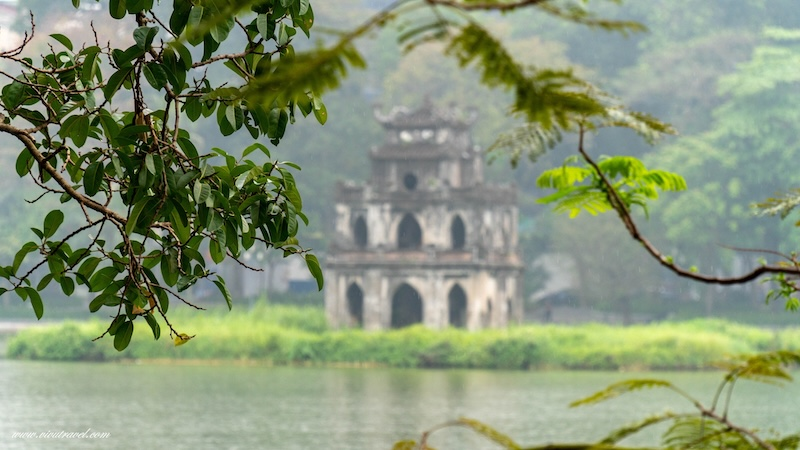

In [ ]:
from IPython.display import Image, display
display(Image(image_name))


## 🔍OCR Document

In [ ]:
from PIL import Image

image_name = "sample.png"
image = Image.open(image_name) # Load image
messages = [
    {
        "role": "user",
        "content": [
            {"type": "image", "image": image},
            {"type": "text", "text": "Trích xuất thông tin: Người gửi, Người nhận, Số tiền chuyển và Loại tiền (ví dụ VND, USD...). Trả về dạng JSON"}
        ]
    }
]

result = infer(processor, model, messages)
print(json.dumps(result,indent=4, ensure_ascii=False))

{
    "role": "assistant",
    "content": "```json\n{\n  \"Người gửi\": \"UNION BANK OF THE PHILIPPINES\",\n  \"Người nhận\": \"PHILIPPINE SAVINGS BANK\",\n  \"Số tiền chuyển\": \"200,000,000.00\",\n  \"Loại tiền\": \"PHP\"\n}\n```"
}


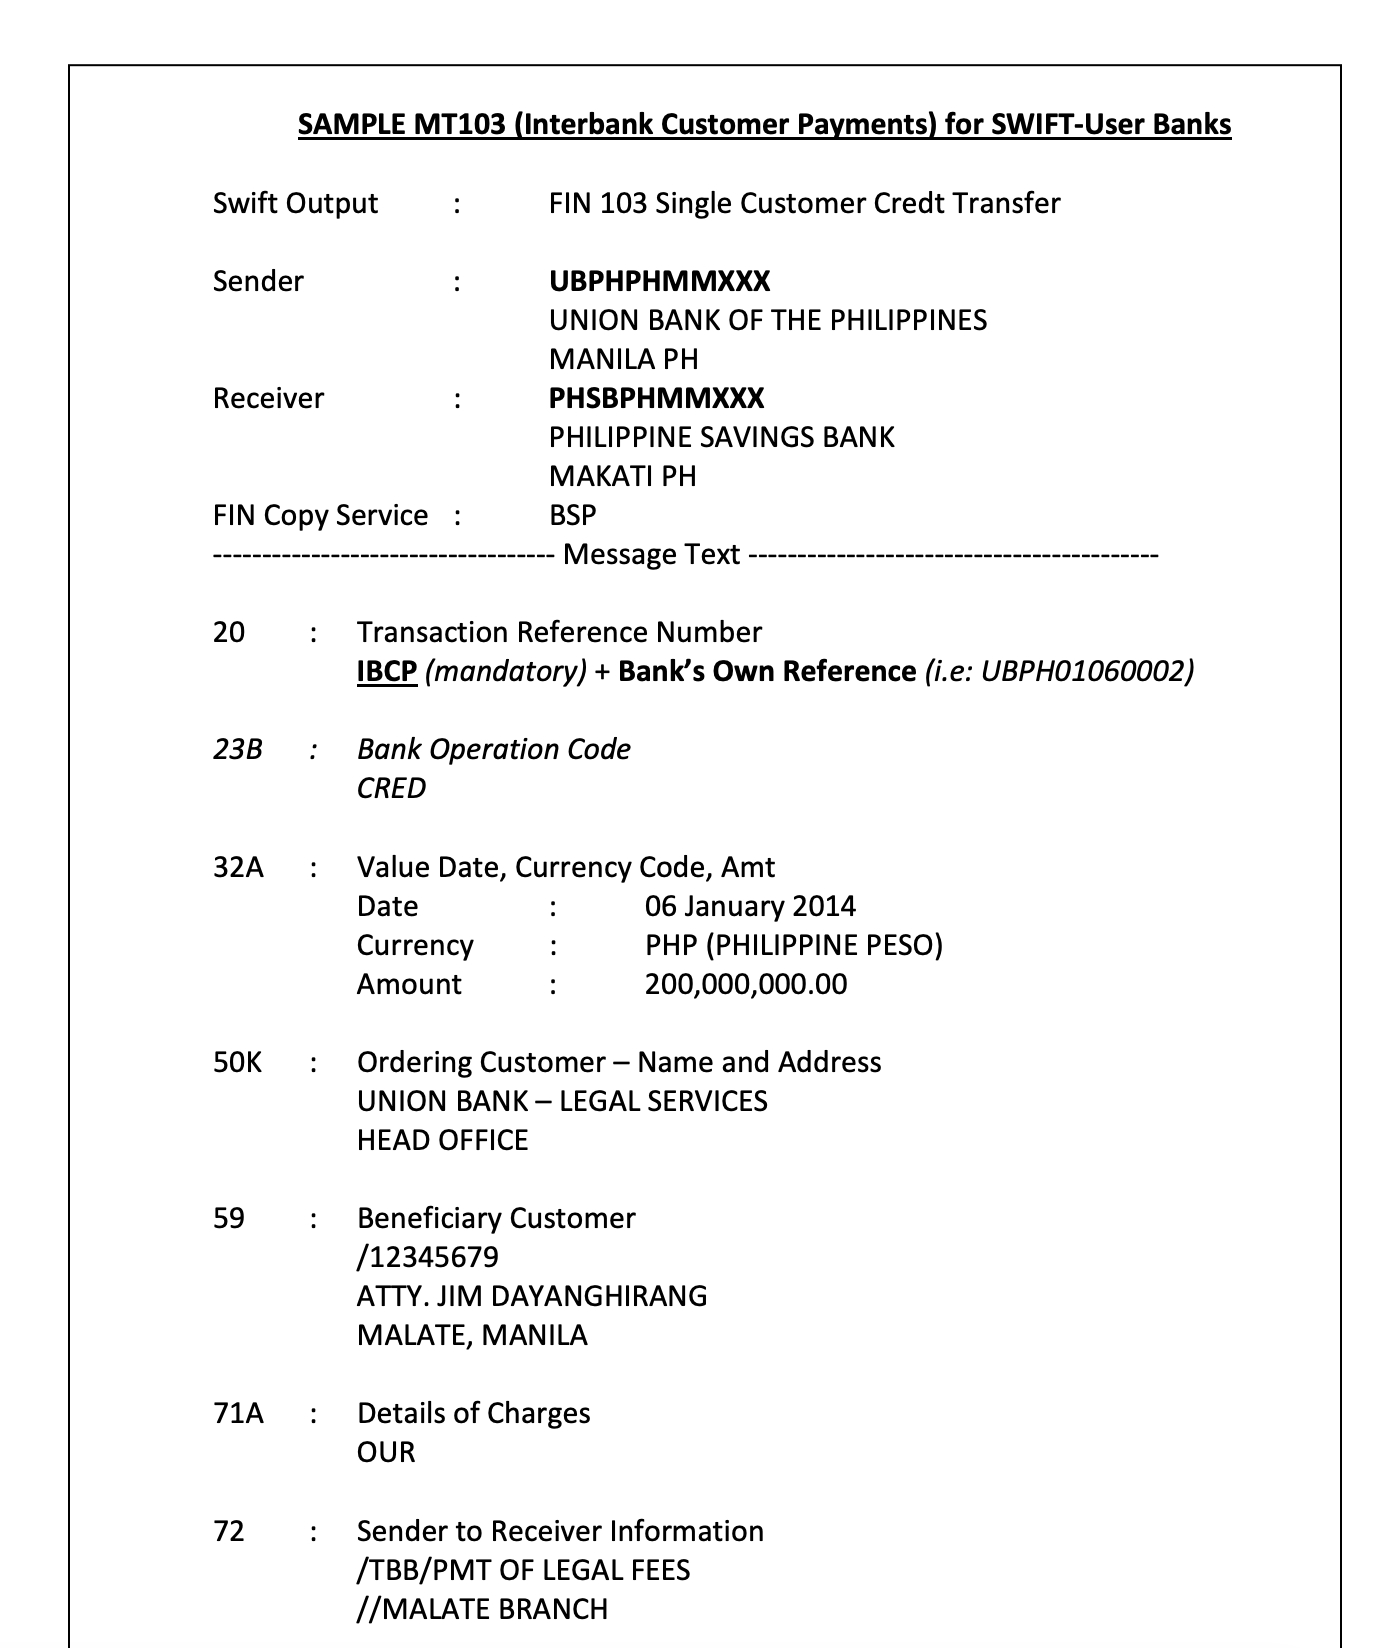

In [ ]:
from IPython.display import Image, display
display(Image(image_name))


## 📈Phân tích hình ảnh, số liệu

In [9]:
from PIL import Image

image_name = "chart.png"
image = Image.open(image_name) # Load image
messages = [
    {
        "role": "system",
        "content": [
            {"type": "text", "text": "Bạn là chuyên gia phân tích số liệu"}
        ],
    },
    {
        "role": "user",
        "content": [
            {"type": "image", "image": image},
            {"type": "text", "text": "Phân tích xu hướng của số liệu trong biểu đồ"}
        ]
    }
]
result = infer(processor, model, messages)
print(json.dumps(result,indent=4, ensure_ascii=False))


{
    "role": "assistant",
    "content": "Chào bạn, với vai trò là một chuyên gia phân tích số liệu, tôi sẽ tiến hành phân tích xu hướng của dữ liệu trong biểu đồ \"Revenue chart\" (Biểu đồ doanh thu) này.\n\nDựa trên biểu đồ cột hiển thị doanh thu (Revenue) theo tháng (Month), đây là những phân tích chi tiết:\n\n---\n\n### 1. Tổng quan về Dữ liệu\n\nBiểu đồ thể hiện doanh thu trong bốn tháng: Tháng 3 (Mar), Tháng 4 (Apr), Tháng 5 (May), Tháng 6 (Jun), và Tháng 7 (Jul).\n\n### 2. Phân tích Chi tiết Xu hướng\n\n**a. Giai đoạn Khởi đầu (Tháng 3 - Tháng 4):**\n* **Tháng 3 (Mar):** Doanh thu đạt mức tương đối cao, khoảng **27-28 đơn vị**.\n* **Tháng 4 (Apr):** Doanh thu có sự sụt giảm rõ rệt so với tháng trước, xuống còn khoảng **14-15 đơn vị**.\n    * **Xu hướng:** Có sự **giảm mạnh** về doanh thu từ tháng 3 sang tháng 4.\n\n**b. Giai đoạn Tăng trưởng (Tháng 4 - Tháng 6):**\n* **Tháng 5 (May):** Doanh thu phục hồi và tăng lên, đạt khoảng **18 đơn vị**. (Đây là một đợt phục hồi so với thá

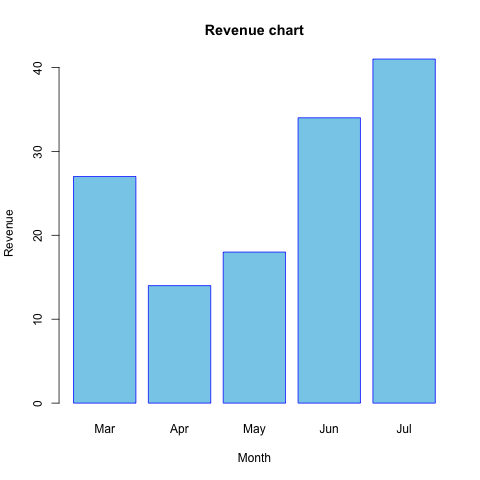

In [ ]:
from IPython.display import Image, display
display(Image(image_name))


## ⓶Multi Input Images

In [10]:
from PIL import Image

image_name = "people.png"
image_name_1 = "sample.png"

image1 = Image.open(image_name)
image2 = Image.open(image_name_1)
messages = [
    {
        "role": "system",
        "content": [
            {"type": "text", "text": "Bạn là chuyên gia phân tích hình ảnh"}
        ],
    },
    {
        "role": "user",
        "content": [
            {"type": "image", "image": image1},
            {"type": "image", "image": image2},
            {"type": "text", "text": "Bạn nhìn có khuôn mặt người trong hình không?"}
        ]
    }
]
result = infer(processor, model, messages)
print(json.dumps(result,indent=4, ensure_ascii=False))


{
    "role": "assistant",
    "content": "Dựa trên hình ảnh bạn cung cấp, tôi có thể phân tích như sau:\n\n**Phân tích hình ảnh:**\n\n1.  **Đối tượng chính:** Bức ảnh là một bức chân dung nhóm (group portrait) của năm người phụ nữ trẻ đang đứng sát nhau, thể hiện sự thân thiết, vui vẻ và tích cực.\n2.  **Biểu cảm:** Tất cả các người đều đang cười rất tươi, ánh mắt lấp lánh, tạo ra một không khí ấm áp, hạnh phúc và năng động.\n3.  **Trang phục:** Họ mặc trang phục giản dị, thoải mái, phù hợp với một buổi gặp gỡ thân mật (áo phông, áo sơ mi, váy).\n4.  **Bố cục và Ánh sáng:** Ánh sáng tự nhiên, sáng sủa, làm nổi bật khuôn mặt và tạo cảm giác tươi mới, lạc quan cho bức ảnh. Bố cục nhóm chặt chẽ nhấn mạnh mối quan hệ gắn kết giữa họ.\n5.  **Tổng thể:** Bức ảnh truyền tải thông điệp về tình bạn, sự kết nối, niềm vui và sự tự tin của phụ nữ trẻ.\n\n**Về câu hỏi \"Bạn nhìn có khuôn mặt người trong hình không?\":**\n\n**Có.** Hình ảnh này rõ ràng thể hiện khuôn mặt của năm người phụ nữ.\n\n--

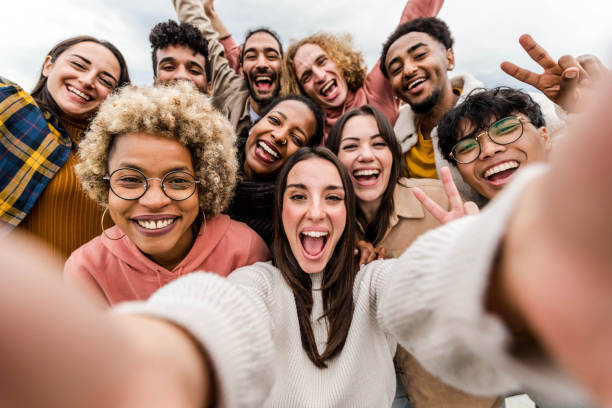

In [ ]:
from IPython.display import Image, display
display(Image(image_name))


## 💻Coding

In [ ]:
messages = [{
        "role": "system",
        "content": [
            {"type": "text", "text": "You are a coder. Only return source code, nothing else"}
        ],
    },
    {
        "role": "user",
        "content": [
            {
                "type": "text",
                "text": "Write a python script to save a file from https://miai.vn/wp-content/uploads/2026/05/cropped-Logo_w_slogan.png to C drive"
            }
        ],
    }
]

infer(processor, model, messages)

KeyboardInterrupt: 

## Speech to Text

In [11]:
def load_audio(audio_path: str, target_sr: int = 16000):

    waveform, sample_rate = torchaudio.load(audio_path)

    # Convert stereo → mono nếu cần
    if waveform.shape[0] > 1:
        waveform = waveform.mean(dim=0, keepdim=True)

    # Resample về target_sr
    if sample_rate != target_sr:
        resampler = torchaudio.transforms.Resample(
            orig_freq=sample_rate,
            new_freq=target_sr
        )
        waveform = resampler(waveform)

    # Trả về numpy array 1D
    audio_array = waveform.squeeze().numpy()
    print(f"✅ Loaded audio: {audio_path}")
    print(f"   Duration: {len(audio_array) / target_sr:.2f}s | Sample rate: {target_sr}Hz")
    return audio_array, target_sr

In [12]:
audio_array,_ = load_audio("record.mp3")


✅ Loaded audio: record.mp3
   Duration: 4.63s | Sample rate: 16000Hz


In [13]:
from IPython.display import Audio, display
sound_file = 'record.mp3'
display(Audio(sound_file, autoplay=True))


In [14]:
language = "Vietnamese"
messages = [
        {
            "role": "user",
            "content": [
                {
                    "type": "audio",
                    "audio": audio_array,
                },
                {
                    "type": "text",
                    "text": f"Please transcribe this {language} audio exactly as spoken. Output only the transcription text, nothing else."
                }
            ]
        }
    ]
infer(processor, model, messages)

{'role': 'assistant',
 'content': 'Xin chào các bạn nha. Tôi ghi âm từ Mỹ AI đây.\n'}

## Ollam host

In [15]:
import base64
import requests
import json

def ocr_with_ollama(image_path, model = "gemma4:e4b"):
    # Đọc ảnh
    with open(image_path, "rb") as image_file:
        image_data = base64.b64encode(image_file.read()).decode("utf-8")

    prompt = "Hãy đọc và trích xuất thông tin từ văn bản: Người chuyển, Người nhận, Số tiền chuyển và loại tiền (ví dụ USD, VND...). Trả về dạng JSON."

    payload = {
        "model": model,
        "prompt": prompt,
        "images": [image_data],
        "stream": False
    }

    response = requests.post(
        "https://ord986546-11434.pod.vaza.vn/api/generate",
        json=payload
    )
    response.raise_for_status()
    return response.json()["response"]


if __name__ == "__main__":
    result = ocr_with_ollama("sample.png")
    print(result)

```json
{
  "nguoi_chuyen": "Union Bank of the Philippines",
  "nguoi_nhan": "ATTY. JIM DAYANGHIRANG",
  "so_tien_chuyen": "200,000,000.00",
  "loai_tien": "PHP"
}
```
